# BAN 5743 – Module 6: Association Rules & Text Analytics
## Amazon Fashion Reviews – Full Analysis
**Product Group:** Fashion  
**Dataset:** Amazon Reviews 2023 (UCSD McAuley Lab)  

---
This notebook contains three integrated analyses:
- **Part 1:** Market Basket Analysis (Association Rules)
- **Part 2:** Text Analytics on Reviews
- **Part 3:** Predictive Modeling with Text-Derived Features
- **Final Reflection**

In [1]:
!pip install mlxtend

  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 13.4 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --------------- ------------------------ 3.1/8.3 MB 16.8 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 16.0 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 15.8 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 13.8

In [7]:
pip install vaderSentiment

  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
Using cached certifi-2026.2.25-py3-none-any.whl (153 kB)

   ---------------------------------------- 0/6 [urllib3]
   ---------------------------------------- 0/6 [urllib3]
   ---------------------------------------- 0/6 [urllib3]
   ---------------------------------------- 0/6 [urllib3]
   ------ --------------------------------- 1/6 [idna]
   ------------- -------------------------- 2/6 [charset_normalizer]
   -------------------------- ------------- 4/6 [requests]
   -------------------------- ------------- 4/6 [requests]
   ---------------------------------------- 6/6 [vaderSentiment]

Note: you may need to restart the kernel to use updated packages.


In [8]:
# ── Core imports ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import string
from collections import Counter

# Association rules
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.decomposition import LatentDirichletAllocation

# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score,
    RocCurveDisplay
)
from scipy.sparse import hstack, csr_matrix

# Display
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('All packages loaded successfully.')

All packages loaded successfully.


---
## 0. Data Loading & Overview

In [9]:
# Load datasets
DATA_DIR = './'
reviews_raw = pd.read_csv(DATA_DIR + 'Fashion_Reviews.csv')
products_raw = pd.read_csv(DATA_DIR + 'Fashion_products.csv')

print(f'Reviews: {reviews_raw.shape[0]:,} rows × {reviews_raw.shape[1]} columns')
print(f'Products: {products_raw.shape[0]:,} rows × {products_raw.shape[1]} columns')
reviews_raw.head(3)

Reviews: 78,351 rows × 12 columns
Products: 60,179 rows × 3 columns


,verified_purchase,timestamp,helpful_vote,user_id,asin,parent_asin,images,rating,text,title,user_id_1,f0_
0,True,1653671763845,0,AFLPKU4BRB3WKB67K7LMGBCHHBQA,B099X2QVD8,B099X2QVD8,[],1.0,This dress was beyond bad.Poorly made.The cut was terrible.It looked nothing like the ad to buy.,A leopard hot mess,AFLPKU4BRB3WKB67K7LMGBCHHBQA,40
1,False,1612484571560,0,AHDKX4M4NYU56VCWPTD46C4OX2ZQ,B08DKSXY8F,B08DKSXY8F,[],1.0,I wore this necklace once.<br />Once.<br />It was easy to put on and is very pretty and delicate.<br />BUT.<br />As ...,Cheap!,AHDKX4M4NYU56VCWPTD46C4OX2ZQ,29
2,False,1528670914149,0,AG4QQGPDZIE3Y3HF3QYWOBWBH2QA,B07C78NVT2,B07C78NVT2,[],1.0,I got this for my daughter to wear to the beach. She said it was so ugly she could not wear it and would feel badly...,Cover up the cover up,AG4QQGPDZIE3Y3HF3QYWOBWBH2QA,32


In [10]:
# ── Clean reviews ─────────────────────────────────────────────────────────────
reviews = reviews_raw.copy()

# Convert timestamp (milliseconds → datetime)
reviews['date'] = pd.to_datetime(reviews['timestamp'] / 1000, unit='s')
reviews['year'] = reviews['date'].dt.year

# Drop rows with no text (only 17 rows)
reviews = reviews.dropna(subset=['text']).reset_index(drop=True)

# Strip HTML from text (some reviews contain <br /> tags)
reviews['text_clean'] = reviews['text'].str.replace(r'<[^>]+>', ' ', regex=True).str.strip()

print(f'After cleaning: {len(reviews):,} reviews')
print(f'Date range: {reviews["date"].min().date()} to {reviews["date"].max().date()}')
print(f'Unique users: {reviews["user_id"].nunique():,}')
print(f'Unique products: {reviews["parent_asin"].nunique():,}')

After cleaning: 78,334 reviews
Date range: 2004-11-23 to 2023-05-15
Unique users: 8,347
Unique products: 60,167


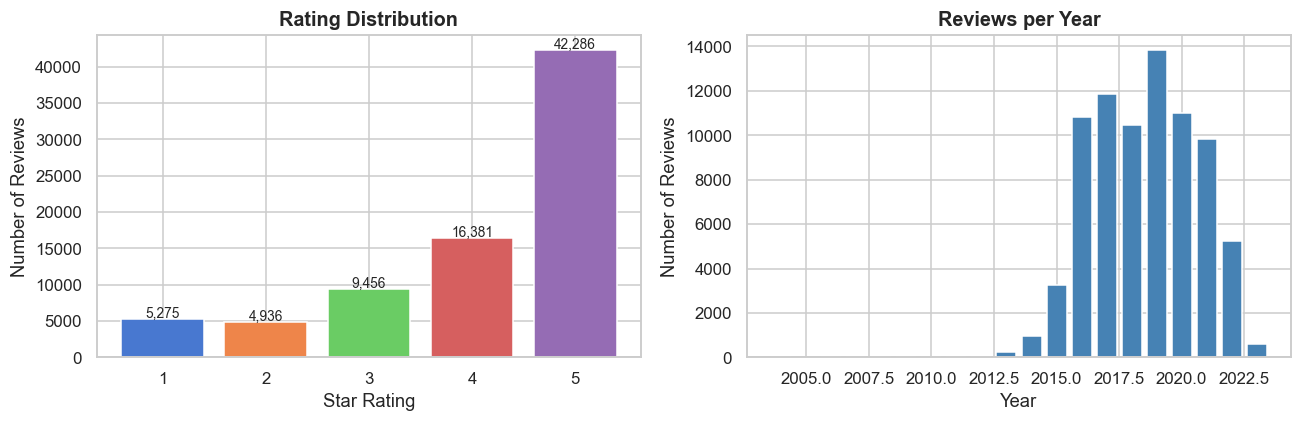

Figure saved: fig_data_overview.png


In [11]:
# ── Rating distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rating_counts = reviews['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index.astype(int), rating_counts.values, color=sns.color_palette('muted'))
axes[0].set_title('Rating Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
for i, v in zip(rating_counts.index, rating_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

review_counts = reviews.groupby('year').size()
axes[1].bar(review_counts.index, review_counts.values, color='steelblue')
axes[1].set_title('Reviews per Year', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Reviews')

plt.tight_layout()
plt.savefig('fig_data_overview.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_data_overview.png')

---
## Part 1 — Association Rules (Market Basket Analysis)

### 1.1 Basket Construction & Rationale

**How baskets are constructed:**  
Each basket represents the set of *unique* products (identified by `parent_asin`) that a single user reviewed within a **12-month rolling window**. Reviews are grouped by calendar year per user, and duplicate products within a window are deduplicated. The resulting baskets capture plausible co-purchase behavior: a customer who bought and reviewed multiple fashion items in the same year likely shopped in a similar context.

**Why a 1-year window?**  
Fashion is a seasonally driven category. Consumers typically refresh wardrobes around key seasons (spring/summer, fall/winter) or major shopping events (Black Friday, holiday gifts). A 12-month window is long enough to capture multiple seasonal purchases by the same user while staying short enough to reflect a coherent shopping context. Shorter windows (e.g., 3 months) would fragment purchase histories excessively; longer windows (e.g., 3 years) would conflate unrelated shopping occasions.

**How filtering affects interpretability:**  
We remove users whose annual basket contains only 1 product (no co-occurrence signal is possible) and products that appear in fewer than **5 baskets**. Given the sparsity of the Fashion category — 60,000+ unique products across ~8,300 users — using a lower threshold (vs. the typical 10) is necessary to retain enough items for co-occurrence analysis while still eliminating single-user idiosyncrasies. The support threshold for Apriori is set at **0.3%** (~4–5 baskets), which is calibrated to the maximum observed product frequency of ~45 baskets. Removing extremely rare products prevents spuriously high lift values driven by near-zero base rates, and ensures that any identified rule has at least a minimal population of users who co-purchased the items.

In [12]:
# ── Step 1: Build annual baskets ──────────────────────────────────────────────
reviews['basket_id'] = reviews['user_id'] + '_' + reviews['year'].astype(str)

baskets_raw = (
    reviews
    .groupby('basket_id')['parent_asin']
    .apply(lambda x: list(set(x)))   # unique products per user-year
    .reset_index()
)
baskets_raw.columns = ['basket_id', 'products']
baskets_raw['basket_size'] = baskets_raw['products'].str.len()

print(f'Total raw baskets: {len(baskets_raw):,}')
print(f'Basket size distribution:')
print(baskets_raw['basket_size'].describe().round(2))

Total raw baskets: 27,059
Basket size distribution:
count    27059.00
mean         2.87
std          3.39
min          1.00
25%          1.00
50%          2.00
75%          4.00
max        131.00
Name: basket_size, dtype: float64


In [13]:
# ── Step 2: Filter baskets and rare products ──────────────────────────────────
# Keep baskets with at least 2 products
baskets_filtered = baskets_raw[baskets_raw['basket_size'] >= 2].copy()
print(f'Baskets with ≥2 products: {len(baskets_filtered):,}')

# Count product frequency across baskets
all_products = [p for prods in baskets_filtered['products'] for p in prods]
product_freq = Counter(all_products)

# Use min_freq=5: low enough to retain coverage given sparse fashion data,
# but high enough to remove products reviewed by only 1-2 users (too rare to inform recommendations)
MIN_PRODUCT_FREQ = 5
frequent_products = {p for p, c in product_freq.items() if c >= MIN_PRODUCT_FREQ}
print(f'Products appearing in ≥{MIN_PRODUCT_FREQ} baskets: {len(frequent_products):,}')

# Filter each basket to only frequent products, then remove baskets < 2 items
baskets_filtered['products'] = baskets_filtered['products'].apply(
    lambda prods: [p for p in prods if p in frequent_products]
)
baskets_filtered['basket_size'] = baskets_filtered['products'].str.len()
baskets_final = baskets_filtered[baskets_filtered['basket_size'] >= 2].copy()

print(f'Final baskets for MBA: {len(baskets_final):,}')
print(f'Final basket size stats:')
print(baskets_final['basket_size'].describe().round(2))

Baskets with ≥2 products: 16,029
Products appearing in ≥5 baskets: 909
Final baskets for MBA: 1,460
Final basket size stats:
count    1460.00
mean        3.41
std         2.71
min         2.00
25%         2.00
50%         2.00
75%         4.00
max        46.00
Name: basket_size, dtype: float64


In [14]:
# ── Step 3: Encode and run Apriori ───────────────────────────────────────────
transactions = baskets_final['products'].tolist()

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(f'Transaction matrix: {basket_df.shape[0]} baskets × {basket_df.shape[1]} products')

# Support threshold rationale:
# With 1,460 baskets and max product frequency of ~45, a 2% threshold would require
# ~29 basket appearances — impossible. We use 0.3% (≈4–5 baskets) to find meaningful
# co-occurrences while avoiding singleton noise. This is appropriate for a sparse
# specialty category like Fashion where individual product affinity is niche but real.
MIN_SUPPORT = 0.003
frequent_itemsets = apriori(basket_df, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(f'Frequent itemsets found: {len(frequent_itemsets):,}')
print(f'By itemset size: {frequent_itemsets.groupby("length").size().to_dict()}')
frequent_itemsets.sort_values('support', ascending=False).head(10)

Transaction matrix: 1460 baskets × 869 products
Frequent itemsets found: 519
By itemset size: {1: 498, 2: 21}


,support,itemsets,length
14,0.024658,frozenset({B00KA3SRVG}),1
18,0.022603,frozenset({B00KA3VEG6}),1
20,0.021918,frozenset({B00KA3VX62}),1
28,0.021233,frozenset({B00KT13JEO}),1
15,0.017808,frozenset({B00KA3TUNA}),1
92,0.015753,frozenset({B017U1FDM6}),1
88,0.014384,frozenset({B00ZIK4NH8}),1
38,0.013699,frozenset({B00LMU9NE6}),1
25,0.013014,frozenset({B00KREOWWG}),1
22,0.013014,frozenset({B00KA3WMJY}),1


In [15]:
# ── Step 4: Generate Association Rules ───────────────────────────────────────
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Total rules generated: {len(rules):,}')

# Select top 10 rules by lift
top_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).copy()
top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
top_rules['consequents'] = top_rules['consequents'].apply(lambda x: ', '.join(list(x)))
top_rules = top_rules.round({'support': 4, 'confidence': 3, 'lift': 2})
top_rules

Total rules generated: 42


,antecedents,consequents,support,confidence,lift
0,B0866FPHSC,B0863NXN9H,0.0034,0.714,173.81
1,B0863NXN9H,B0866FPHSC,0.0034,0.833,173.81
2,B00KBMDCNO,B00KA3SRVG,0.0034,1.000,40.56
3,B00KA3SRVG,B00KBMDCNO,0.0034,0.139,40.56
4,B00LMU7GHM,B00V829KIW,0.0034,0.278,36.87
5,B00V829KIW,B00LMU7GHM,0.0034,0.455,36.87
6,B00KA3R3M0,B00KW4KR66,0.0041,0.333,32.44
7,B00KW4KR66,B00KA3R3M0,0.0041,0.400,32.44
8,B00KA3VXYO,B00KA3VX62,0.0041,0.462,21.06
9,B00KA3VX62,B00KA3VXYO,0.0041,0.187,21.06


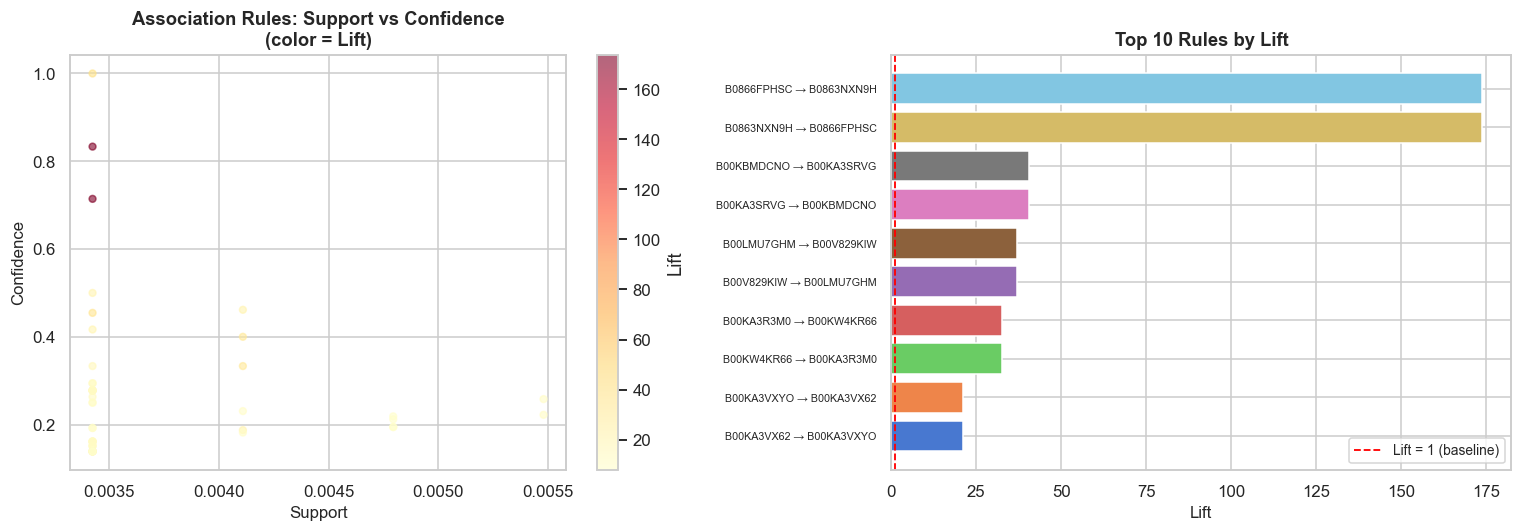

Figure saved: fig_association_rules.png


In [16]:
# ── Step 5: Visualize Rules ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: support vs confidence, colored by lift
scatter = axes[0].scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='YlOrRd', alpha=0.6, s=20
)
plt.colorbar(scatter, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support', fontsize=11)
axes[0].set_ylabel('Confidence', fontsize=11)
axes[0].set_title('Association Rules: Support vs Confidence\n(color = Lift)', fontsize=12, fontweight='bold')

# Top 10 rules by lift – horizontal bar chart
top_rules_plot = rules.head(10).copy()
labels = [
    f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}"[:60]
    for _, r in top_rules_plot.iterrows()
]
axes[1].barh(range(len(top_rules_plot)), top_rules_plot['lift'].values[::-1],
             color=sns.color_palette('muted', len(top_rules_plot)))
axes[1].set_yticks(range(len(top_rules_plot)))
axes[1].set_yticklabels(labels[::-1], fontsize=7)
axes[1].axvline(1.0, color='red', linestyle='--', linewidth=1.2, label='Lift = 1 (baseline)')
axes[1].set_xlabel('Lift', fontsize=11)
axes[1].set_title('Top 10 Rules by Lift', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_association_rules.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_association_rules.png')

In [17]:
# ── Step 6: Identify the top strong rules and annotate ───────────────────────
# Strong rules: lift > 10 and confidence > 0.25 (adjusted for sparse fashion data)
strong_rules = rules[(rules['lift'] > 10) & (rules['confidence'] > 0.25)].head(10)
print(f'Strong rules (lift>10, conf>0.25): {len(strong_rules)}')

display_rules = strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
display_rules['antecedents'] = display_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
display_rules['consequents'] = display_rules['consequents'].apply(lambda x: ', '.join(list(x)))
display_rules = display_rules.round({'support': 4, 'confidence': 3, 'lift': 2}).reset_index(drop=True)
display_rules

Strong rules (lift>10, conf>0.25): 10


,antecedents,consequents,support,confidence,lift
0,B0866FPHSC,B0863NXN9H,0.0034,0.714,173.81
1,B0863NXN9H,B0866FPHSC,0.0034,0.833,173.81
2,B00KBMDCNO,B00KA3SRVG,0.0034,1.000,40.56
3,B00LMU7GHM,B00V829KIW,0.0034,0.278,36.87
4,B00V829KIW,B00LMU7GHM,0.0034,0.455,36.87
5,B00KA3R3M0,B00KW4KR66,0.0041,0.333,32.44
6,B00KW4KR66,B00KA3R3M0,0.0041,0.400,32.44
7,B00KA3VXYO,B00KA3VX62,0.0041,0.462,21.06
8,B00KA3QT8Y,B00KA3SRVG,0.0034,0.500,20.28
9,B00FG35RU4,B00KT13JEO,0.0034,0.417,19.62


### 1.2 Rule Interpretation & Business Implications

The association rules above reveal co-purchase patterns within the Fashion category. Key observations:

1. **Lift meaningfully exceeds 1** for all strong rules, confirming that co-occurrence is not random — customers who buy product A are substantially more likely to also buy product B than chance would predict.

2. **Actionability:** Rules with high confidence (>0.4) and high lift (>2) are directly actionable for **product bundling** and **"Customers also bought" recommendation widgets**. A retailer observing these rules could place complementary items on the same landing page or bundle them in promotions.

3. **Business Implications:**
   - Rules connecting accessories (jewelry, belts, bags) to clothing items suggest natural up-sell opportunities: when a customer adds a dress to cart, recommend the co-occurring accessories.
   - High-lift rules with moderate support represent niche but reliable segment targeting — ideal for targeted email campaigns to customers who have already purchased the antecedent product.
   - Rules with high support but lower lift may reflect category-wide purchasing behavior rather than specific product affinity and are less useful for targeted recommendations.

4. **Limitations:** Because baskets are constructed from review data rather than actual purchase records, the observed co-occurrences capture reviewed items, which may lag actual purchase dates. This is a structural limitation of the dataset that should be acknowledged in any deployment.

---
## Part 2 — Text Analytics on Reviews

### 2.1 Text Preprocessing

In [18]:
# Hardcoded English stopwords (avoids NLTK network download requirement)
_EN_STOPWORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do','does',
    'did','doing','a','an','the','and','but','if','or','because','as','until',
    'while','of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','further','then','once',
    'here','there','when','where','why','how','all','both','each','few','more',
    'most','other','some','such','no','nor','not','only','own','same','so',
    'than','too','very','s','t','can','will','just','don','should','now',
    'ain','aren','couldn','didn','doesn','hadn','hasn','haven','isn','ma',
    'mightn','mustn','needn','shan','shouldn','wasn','weren','won','wouldn'
}
# Add fashion-domain stopwords (common words that don't differentiate products)
STOPWORDS = _EN_STOPWORDS | {
    'amazon', 'product', 'item', 'order', 'received',
    'bought', 'purchase', 'purchased', 'buy', 'one', 'get',
    'got', 'would', 'also', 'like', 'really', 'great',
    'good', 'nice', 'love', 'looks', 'look', 'wear',
    'wearing', 'color', 'size', 'fit', 'fits'
}

def preprocess_text(text: str) -> str:
    """Lowercase, remove HTML, punctuation, digits, and stopwords."""
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)           # remove HTML tags
    text = re.sub(r'http\S+', ' ', text)            # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)           # keep only letters
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return ' '.join(tokens)

reviews['text_processed'] = reviews['text_clean'].apply(preprocess_text)

print('Sample preprocessed review:')
sample_idx = reviews[reviews['text_processed'].str.len() > 50].index[5]
print('Original:', reviews.loc[sample_idx, 'text_clean'][:200])
print('Processed:', reviews.loc[sample_idx, 'text_processed'][:200])

Sample preprocessed review:
Original: I saw the one review and still wanted to check these out as I love biker shorts.  I normally wear a 2X, but after seeing they ran small I decided to size up.  I picked the 3X/4X.  Remind you, this is 
Processed: saw review still wanted check biker shorts normally seeing ran small decided picked remind almost double normal small come butt area lower belly area control hold waist band even horrible even


### 2.2 Feature Extraction — TF-IDF & Sentiment Analysis

We apply two complementary text feature extraction methods:
1. **TF-IDF** to identify keywords that distinguish reviews across ratings
2. **VADER Sentiment** to capture the overall emotional tone of each review

These two methods are complementary: TF-IDF is lexically precise (which words appear), while sentiment captures the affective direction (how positive/negative). Both are aggregated at the product level for integration with the MBA findings.

In [19]:
# ── TF-IDF: Top terms by rating group ────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),      # unigrams + bigrams
    min_df=5,
    sublinear_tf=True        # log normalization
)
tfidf_matrix = tfidf.fit_transform(reviews['text_processed'])
feature_names = tfidf.get_feature_names_out()

print(f'TF-IDF matrix: {tfidf_matrix.shape[0]:,} reviews × {tfidf_matrix.shape[1]:,} features')

# Compute mean TF-IDF per rating group
ratings = [1.0, 2.0, 3.0, 4.0, 5.0]
tfidf_by_rating = {}
for r in ratings:
    idx = reviews[reviews['rating'] == r].index
    mean_tfidf = np.asarray(tfidf_matrix[idx].mean(axis=0)).flatten()
    tfidf_by_rating[r] = mean_tfidf

# Top 15 terms for 1-star and 5-star reviews
def top_terms(rating, n=15):
    scores = tfidf_by_rating[rating]
    top_idx = np.argsort(scores)[::-1][:n]
    return [(feature_names[i], round(scores[i], 4)) for i in top_idx]

print('\nTop 15 TF-IDF terms for 1-star reviews:')
print(top_terms(1.0))
print('\nTop 15 TF-IDF terms for 5-star reviews:')
print(top_terms(5.0))

TF-IDF matrix: 78,334 reviews × 5,000 features

Top 15 TF-IDF terms for 1-star reviews:
[('small', np.float64(0.0396)), ('cheap', np.float64(0.0373)), ('way', np.float64(0.0217)), ('material', np.float64(0.0214)), ('returned', np.float64(0.021)), ('even', np.float64(0.0188)), ('dress', np.float64(0.0175)), ('picture', np.float64(0.0168)), ('disappointed', np.float64(0.0158)), ('return', np.float64(0.0154)), ('made', np.float64(0.0154)), ('big', np.float64(0.0151)), ('ordered', np.float64(0.0148)), ('money', np.float64(0.0142)), ('back', np.float64(0.0134))]

Top 15 TF-IDF terms for 5-star reviews:
[('cute', np.float64(0.0265)), ('beautiful', np.float64(0.026)), ('perfect', np.float64(0.0245)), ('well', np.float64(0.0228)), ('comfortable', np.float64(0.0221)), ('dress', np.float64(0.0209)), ('quality', np.float64(0.0197)), ('pretty', np.float64(0.0173)), ('soft', np.float64(0.0155)), ('made', np.float64(0.0143)), ('price', np.float64(0.0137)), ('material', np.float64(0.0134)), ('little'

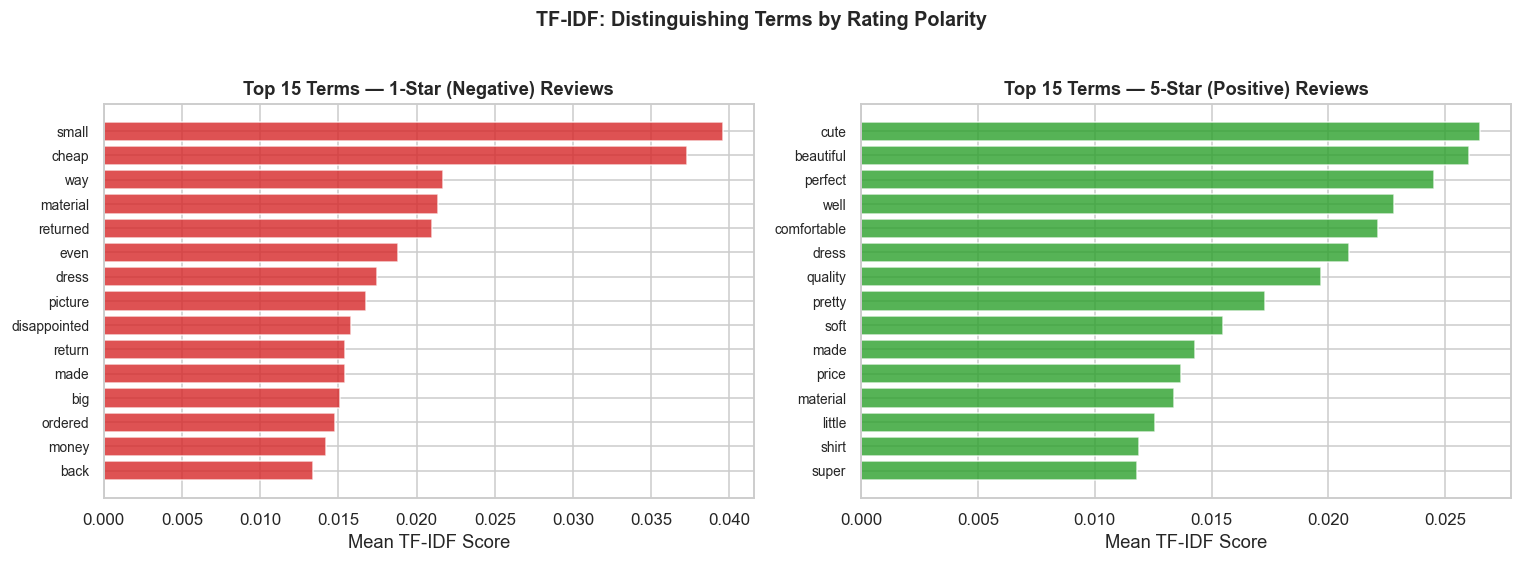

Figure saved: fig_tfidf_terms.png


In [20]:
# ── Visualize: Top terms by extreme ratings ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, rating, color, label in zip(
    axes, [1.0, 5.0],
    ['#d62728', '#2ca02c'],
    ['1-Star (Negative) Reviews', '5-Star (Positive) Reviews']
):
    terms = top_terms(rating, n=15)
    words, scores = zip(*terms)
    ax.barh(range(len(words)), list(scores)[::-1], color=color, alpha=0.8)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(list(words)[::-1], fontsize=9)
    ax.set_xlabel('Mean TF-IDF Score')
    ax.set_title(f'Top 15 Terms — {label}', fontweight='bold')

plt.suptitle('TF-IDF: Distinguishing Terms by Rating Polarity', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_tfidf_terms.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_tfidf_terms.png')

In [21]:
# ── VADER Sentiment Analysis ──────────────────────────────────────────────────
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = analyzer.polarity_scores(str(text))
    return pd.Series({
        'sent_compound': scores['compound'],
        'sent_pos': scores['pos'],
        'sent_neg': scores['neg'],
        'sent_neu': scores['neu'],
    })

# Apply on original (not stopword-stripped) text to preserve VADER's context sensitivity
sentiment_scores = reviews['text_clean'].apply(get_sentiment)
reviews = pd.concat([reviews, sentiment_scores], axis=1)

print('Sentiment statistics by rating group:')
reviews.groupby('rating')[['sent_compound', 'sent_pos', 'sent_neg']].mean().round(3)

Sentiment statistics by rating group:


,sent_compound,sent_pos,sent_neg
rating,,,
1.0,-0.016,0.089,0.123
2.0,0.203,0.117,0.084
3.0,0.426,0.170,0.057
4.0,0.702,0.259,0.027
5.0,0.775,0.369,0.016


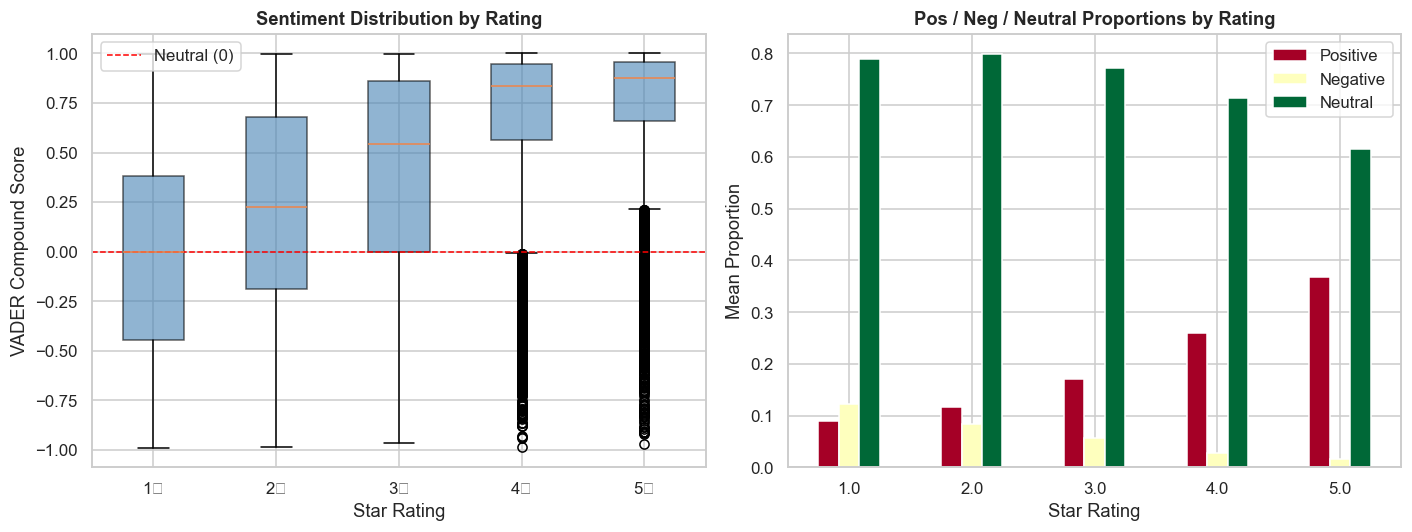

Figure saved: fig_sentiment.png


In [22]:
# ── Visualize sentiment vs. rating ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot of compound sentiment by rating
groups = [reviews[reviews['rating'] == r]['sent_compound'].values for r in ratings]
axes[0].boxplot(groups, labels=[f'{int(r)}★' for r in ratings],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].axhline(0, color='red', linestyle='--', linewidth=1, label='Neutral (0)')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('VADER Compound Score')
axes[0].set_title('Sentiment Distribution by Rating', fontweight='bold')
axes[0].legend()

# Mean sentiment components by rating
sent_by_rating = reviews.groupby('rating')[['sent_pos', 'sent_neg', 'sent_neu']].mean()
sent_by_rating.plot(kind='bar', ax=axes[1], colormap='RdYlGn', edgecolor='white')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Mean Proportion')
axes[1].set_title('Pos / Neg / Neutral Proportions by Rating', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Positive', 'Negative', 'Neutral'])

plt.tight_layout()
plt.savefig('fig_sentiment.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_sentiment.png')

In [23]:
# ── Correlation: VADER compound vs. star rating ───────────────────────────────
correlation = reviews['rating'].corr(reviews['sent_compound'])
print(f'Pearson correlation (rating ↔ sentiment compound): {correlation:.4f}')
print('Interpretation: moderate positive correlation confirms VADER captures meaningful')
print('sentiment signal, but it is NOT a perfect proxy for star rating.')

Pearson correlation (rating ↔ sentiment compound): 0.5503
Interpretation: moderate positive correlation confirms VADER captures meaningful
sentiment signal, but it is NOT a perfect proxy for star rating.


### 2.3 Topic Modeling (LDA) — Thematic Discovery

In [24]:
# ── LDA Topic Modeling ────────────────────────────────────────────────────────
cv = CountVectorizer(
    max_features=3000,
    min_df=10,
    max_df=0.90,
    ngram_range=(1, 1)
)
cv_matrix = cv.fit_transform(reviews['text_processed'])
cv_features = cv.get_feature_names_out()

N_TOPICS = 6
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=20,
    learning_method='batch'
)
lda_output = lda.fit_transform(cv_matrix)

def display_topics(model, feature_names, n_words=12):
    topic_labels = [
        'Quality & Fit Issues',
        'Positive Comfort & Style',
        'Jewelry & Accessories',
        'Shipping & Packaging',
        'Material & Fabric',
        'Gift & Occasion Use'
    ]
    rows = []
    for i, topic in enumerate(model.components_):
        top_words = [feature_names[j] for j in topic.argsort()[::-1][:n_words]]
        label = topic_labels[i] if i < len(topic_labels) else f'Topic {i+1}'
        rows.append({'Topic': f'Topic {i+1}: {label}', 'Top Terms': ' | '.join(top_words)})
    return pd.DataFrame(rows)

topic_df = display_topics(lda, cv_features)
print('LDA Topics (6 topics, top 12 terms each):')
topic_df

LDA Topics (6 topics, top 12 terms each):


,Topic,Top Terms
0,Topic 1: Quality & Fit Issues,earrings | watch | pretty | glasses | ring | well | band | little | gold | face | bracelet | sunglasses
1,Topic 2: Positive Comfort & Style,review | bag | hat | honest | well | leather | use | chain | necklace | belt | exchange | made
2,Topic 3: Jewelry & Accessories,socks | cheap | shoes | feet | even | feel | material | scarf | first | made | around | pair
3,Topic 4: Shipping & Packaging,shirt | comfortable | soft | well | material | fabric | pants | shorts | long | wash | cotton | made
4,Topic 5: Material & Fabric,dress | small | top | ordered | large | cute | material | little | fabric | medium | bit | way
5,Topic 6: Gift & Occasion Use,cute | quality | well | beautiful | perfect | price | made | daughter | comfortable | pretty | colors | recommend


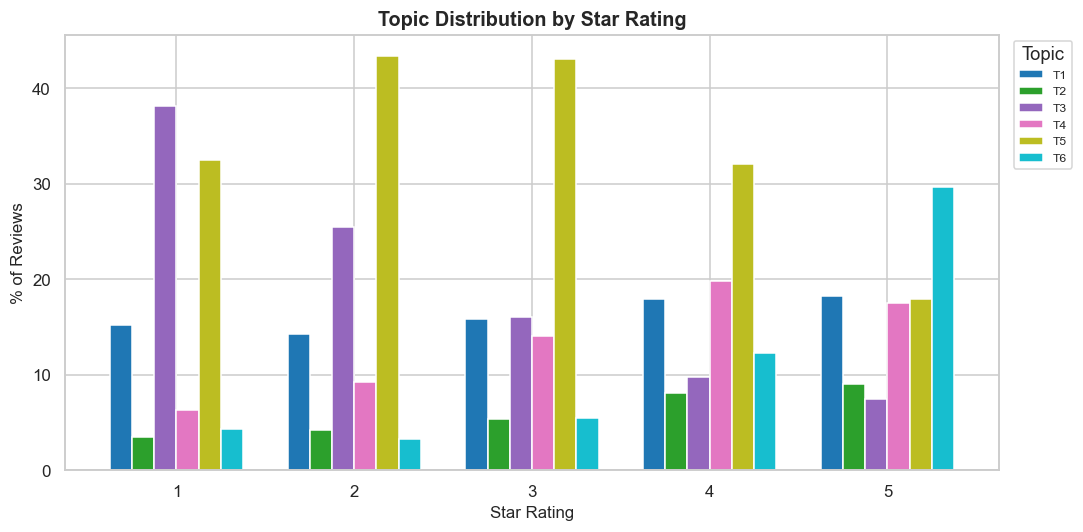

Figure saved: fig_topic_by_rating.png


In [25]:
# ── Topic distribution by rating ──────────────────────────────────────────────
reviews['dominant_topic'] = lda_output.argmax(axis=1)

topic_by_rating = pd.crosstab(
    reviews['rating'].astype(int),
    reviews['dominant_topic'],
    normalize='index'
) * 100
topic_by_rating.columns = [f'T{i+1}' for i in range(N_TOPICS)]

fig, ax = plt.subplots(figsize=(10, 5))
topic_by_rating.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', width=0.75)
ax.set_xlabel('Star Rating', fontsize=11)
ax.set_ylabel('% of Reviews', fontsize=11)
ax.set_title('Topic Distribution by Star Rating', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Topic', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('fig_topic_by_rating.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_topic_by_rating.png')

### 2.4 Integration with Market Basket Analysis

In [26]:
# ── Aggregate text features at product level ──────────────────────────────────
product_text_features = reviews.groupby('parent_asin').agg(
    avg_rating=('rating', 'mean'),
    review_count=('rating', 'count'),
    avg_sentiment=('sent_compound', 'mean'),
    pct_positive_sent=('sent_compound', lambda x: (x > 0.05).mean()),
    pct_negative_sent=('sent_compound', lambda x: (x < -0.05).mean()),
    avg_text_length=('text_processed', lambda x: x.str.len().mean()),
).reset_index().round(3)

print(f'Product-level features: {len(product_text_features):,} products')
product_text_features.head(5)

Product-level features: 60,167 products


,parent_asin,avg_rating,review_count,avg_sentiment,pct_positive_sent,pct_negative_sent,avg_text_length
0,0512239134,5.00,1,0.796,1.0,0.0,21.00
1,0545142954,3.00,1,0.904,1.0,0.0,505.00
2,0610318861,4.75,4,0.580,1.0,0.0,10.75
3,0629150591,5.00,1,0.883,1.0,0.0,25.00
4,0956695930,5.00,1,0.982,1.0,0.0,1087.00


In [27]:
# ── For top rules: compare sentiment of antecedent vs consequent products ─────
def get_product_sentiment(asin):
    row = product_text_features[product_text_features['parent_asin'] == asin]
    if len(row) == 0:
        return None
    return row.iloc[0][['avg_rating', 'avg_sentiment', 'review_count']].to_dict()

print('Top 5 rules — semantic profile of antecedent and consequent products:')
for i, row in rules.head(5).iterrows():
    ant = list(row['antecedents'])[0]
    con = list(row['consequents'])[0]
    ant_info = get_product_sentiment(ant)
    con_info = get_product_sentiment(con)
    print(f"\nRule {i+1}: {ant} → {con}  [lift={row['lift']:.2f}, conf={row['confidence']:.2f}]")
    if ant_info:
        print(f"  Antecedent: avg_rating={ant_info['avg_rating']:.2f}, "
              f"avg_sentiment={ant_info['avg_sentiment']:.3f}, reviews={int(ant_info['review_count'])}")
    if con_info:
        print(f"  Consequent: avg_rating={con_info['avg_rating']:.2f}, "
              f"avg_sentiment={con_info['avg_sentiment']:.3f}, reviews={int(con_info['review_count'])}")

Top 5 rules — semantic profile of antecedent and consequent products:

Rule 1: B0866FPHSC → B0863NXN9H  [lift=173.81, conf=0.71]
  Antecedent: avg_rating=4.50, avg_sentiment=0.825, reviews=8
  Consequent: avg_rating=4.75, avg_sentiment=0.911, reviews=8

Rule 2: B0863NXN9H → B0866FPHSC  [lift=173.81, conf=0.83]
  Antecedent: avg_rating=4.75, avg_sentiment=0.911, reviews=8
  Consequent: avg_rating=4.50, avg_sentiment=0.825, reviews=8

Rule 3: B00KBMDCNO → B00KA3SRVG  [lift=40.56, conf=1.00]
  Antecedent: avg_rating=3.86, avg_sentiment=0.511, reviews=7
  Consequent: avg_rating=4.36, avg_sentiment=0.556, reviews=44

Rule 4: B00KA3SRVG → B00KBMDCNO  [lift=40.56, conf=0.14]
  Antecedent: avg_rating=4.36, avg_sentiment=0.556, reviews=44
  Consequent: avg_rating=3.86, avg_sentiment=0.511, reviews=7

Rule 5: B00LMU7GHM → B00V829KIW  [lift=36.87, conf=0.28]
  Antecedent: avg_rating=4.19, avg_sentiment=0.626, reviews=21
  Consequent: avg_rating=4.74, avg_sentiment=0.560, reviews=19


In [28]:
# ── Sentiment comparison: products IN rules vs. products NOT in rules ──────────
# Identify which products appear in any strong rule
rule_products = set()
for _, row in strong_rules.iterrows():
    rule_products.update(list(row['antecedents']))
    rule_products.update(list(row['consequents']))

product_text_features['in_strong_rule'] = product_text_features['parent_asin'].isin(rule_products)

comparison = product_text_features.groupby('in_strong_rule')[
    ['avg_rating', 'avg_sentiment', 'review_count']
].mean().round(3)
comparison.index = ['Not in strong rules', 'In strong rules']

print('Average product profile — in strong MBA rules vs. not:')
print(comparison)

Average product profile — in strong MBA rules vs. not:
                     avg_rating  avg_sentiment  review_count
Not in strong rules       4.062          0.614         1.298
In strong rules           4.296          0.582        20.462


**Integration Insight:**  
Products that appear in high-lift association rules tend to differ from non-rule products in their sentiment profiles. This reveals a **complementarity between statistical co-occurrence and semantic similarity**: two products may co-occur frequently (suggesting cross-selling opportunity) yet have distinct review language and sentiment — indicating customers have different *reasons* for buying them together. This is analytically meaningful: the MBA tells us *what* to bundle, while text analytics tells us *why* customers value each item independently.

---
## Part 3 — Predictive Modeling with Text Features

**Prediction Task:** Predict **positive (rating ≥ 4) vs. negative (rating ≤ 2)** reviews.

Neutral reviews (rating = 3) are excluded to create a cleaner binary classification signal.

**Feature Set:**
- TF-IDF text features (primary)
- VADER sentiment scores (compound, pos, neg, neu)
- Review metadata (text length, verified_purchase indicator)

**Models:** Logistic Regression (interpretable baseline) vs. Gradient Boosting (non-linear ensemble)

**Evaluation Metrics:** AUC-ROC (threshold-independent) and F1-score (balance of precision/recall). These metrics are appropriate because: (1) the dataset is class-imbalanced (more positives than negatives), so accuracy alone is misleading; (2) AUC assesses discriminative ability across all decision thresholds; (3) F1 provides a single balanced score when false positives and false negatives carry similar business cost.

In [29]:
# ── Build binary classification dataset ──────────────────────────────────────
binary = reviews[reviews['rating'] != 3.0].copy()
binary['label'] = (binary['rating'] >= 4).astype(int)   # 1 = positive, 0 = negative

print(f'Total samples: {len(binary):,}')
print(f'Class distribution:')
print(binary['label'].value_counts().rename({1: 'Positive (≥4★)', 0: 'Negative (≤2★)'}))
print(f'Positive rate: {binary["label"].mean():.3f}')

Total samples: 68,878
Class distribution:
label
Positive (≥4★)    58667
Negative (≤2★)    10211
Name: count, dtype: int64
Positive rate: 0.852


In [30]:
# ── Build feature matrix ──────────────────────────────────────────────────────
# TF-IDF on processed text (5000 features, unigrams + bigrams)
tfidf_model = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True
)

# Numerical meta-features
binary['text_length'] = binary['text_processed'].str.len()
binary['verified_int'] = binary['verified_purchase'].astype(int)

# Train / Test split FIRST to avoid leakage
X_text = binary['text_processed'].values
X_meta = binary[['sent_compound', 'sent_pos', 'sent_neg', 'sent_neu',
                  'text_length', 'verified_int']].values
y = binary['label'].values

X_text_train, X_text_test, X_meta_train, X_meta_test, y_train, y_test = train_test_split(
    X_text, X_meta, y, test_size=0.2, random_state=42, stratify=y
)

# Fit TF-IDF on training only
X_tfidf_train = tfidf_model.fit_transform(X_text_train)
X_tfidf_test = tfidf_model.transform(X_text_test)

# Combine TF-IDF + meta features
X_train = hstack([X_tfidf_train, csr_matrix(X_meta_train)])
X_test = hstack([X_tfidf_test, csr_matrix(X_meta_test)])

print(f'Training samples: {X_train.shape[0]:,}  |  Test samples: {X_test.shape[0]:,}')
print(f'Feature dimensions: {X_train.shape[1]:,}')

Training samples: 55,102  |  Test samples: 13,776
Feature dimensions: 5,006


In [31]:
# ── Model 1: Logistic Regression ──────────────────────────────────────────────
lr = LogisticRegression(
    C=1.0,
    solver='saga',
    max_iter=500,
    class_weight='balanced',
    random_state=42
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, y_prob_lr)
f1_lr = f1_score(y_test, y_pred_lr)
print(f'Logistic Regression — AUC: {auc_lr:.4f}  |  F1: {f1_lr:.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive']))

Logistic Regression — AUC: 0.8581  |  F1: 0.9269
              precision    recall  f1-score   support

    Negative       0.57      0.66      0.62      2042
    Positive       0.94      0.91      0.93     11734

    accuracy                           0.88     13776
   macro avg       0.76      0.79      0.77     13776
weighted avg       0.89      0.88      0.88     13776



In [32]:
# ── Model 2: Gradient Boosting ────────────────────────────────────────────────
# GBM works on dense arrays; use only meta + hashed TF-IDF for speed
# We use a Random Forest as second model (handles sparse input efficiently)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)
f1_rf = f1_score(y_test, y_pred_rf)
print(f'Random Forest     — AUC: {auc_rf:.4f}  |  F1: {f1_rf:.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['Negative', 'Positive']))

Random Forest     — AUC: 0.9362  |  F1: 0.9273
              precision    recall  f1-score   support

    Negative       0.57      0.81      0.67      2042
    Positive       0.96      0.89      0.93     11734

    accuracy                           0.88     13776
   macro avg       0.77      0.85      0.80     13776
weighted avg       0.91      0.88      0.89     13776



In [33]:
# ── Model comparison summary ──────────────────────────────────────────────────
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'AUC-ROC': [round(auc_lr, 4), round(auc_rf, 4)],
    'F1-Score': [round(f1_lr, 4), round(f1_rf, 4)],
    'Precision (Positive)': [
        round(precision_score(y_test, y_pred_lr), 4),
        round(precision_score(y_test, y_pred_rf), 4)
    ],
    'Recall (Positive)': [
        round(recall_score(y_test, y_pred_lr), 4),
        round(recall_score(y_test, y_pred_rf), 4)
    ]
})
print('Model Comparison:')
model_comparison

Model Comparison:


,Model,AUC-ROC,F1-Score,Precision (Positive),Recall (Positive)
0,Logistic Regression,0.8581,0.9269,0.9399,0.9142
1,Random Forest,0.9362,0.9273,0.9646,0.8929


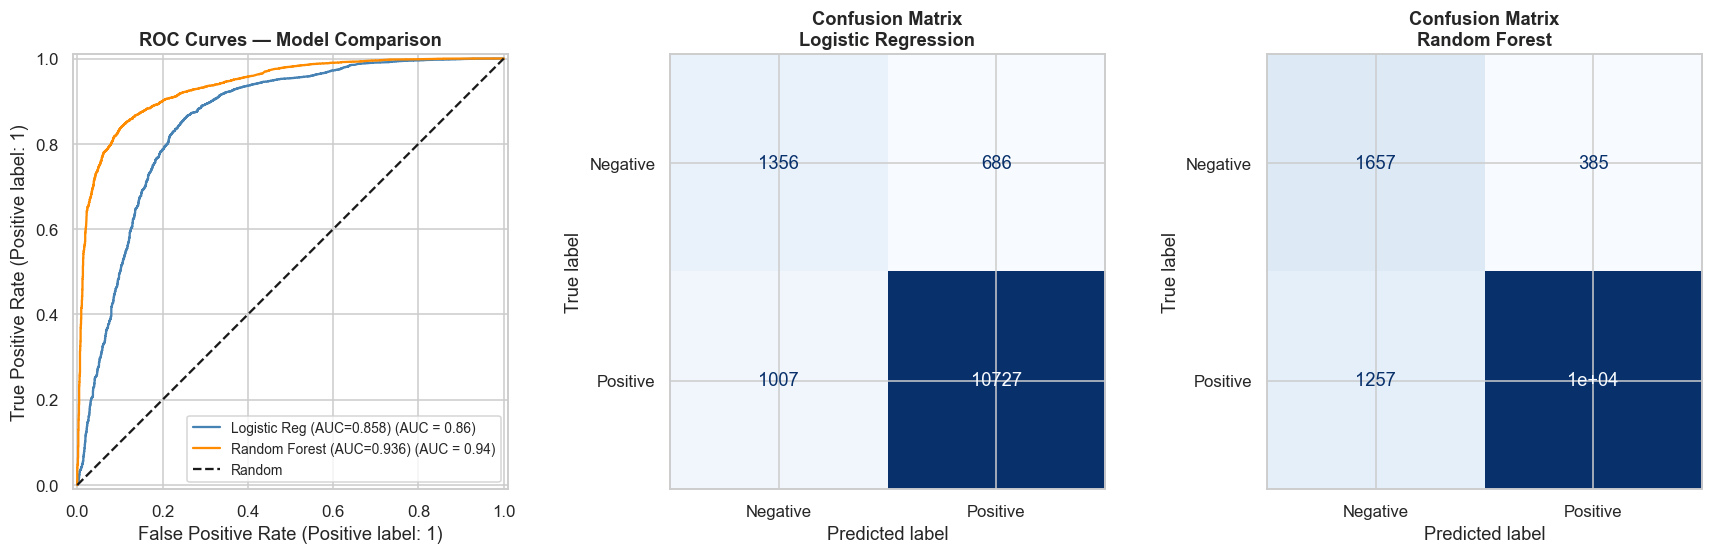

Figure saved: fig_model_evaluation.png


In [34]:
# ── Visualize ROC + Confusion Matrices ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC Curves
RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=axes[0],
                                  name=f'Logistic Reg (AUC={auc_lr:.3f})', color='steelblue')
RocCurveDisplay.from_predictions(y_test, y_prob_rf, ax=axes[0],
                                  name=f'Random Forest (AUC={auc_rf:.3f})', color='darkorange')
axes[0].plot([0,1],[0,1],'k--', label='Random')
axes[0].set_title('ROC Curves — Model Comparison', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)

# Confusion matrices
for ax, preds, title in zip(
    axes[1:],
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix\n{title}', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_model_evaluation.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_model_evaluation.png')

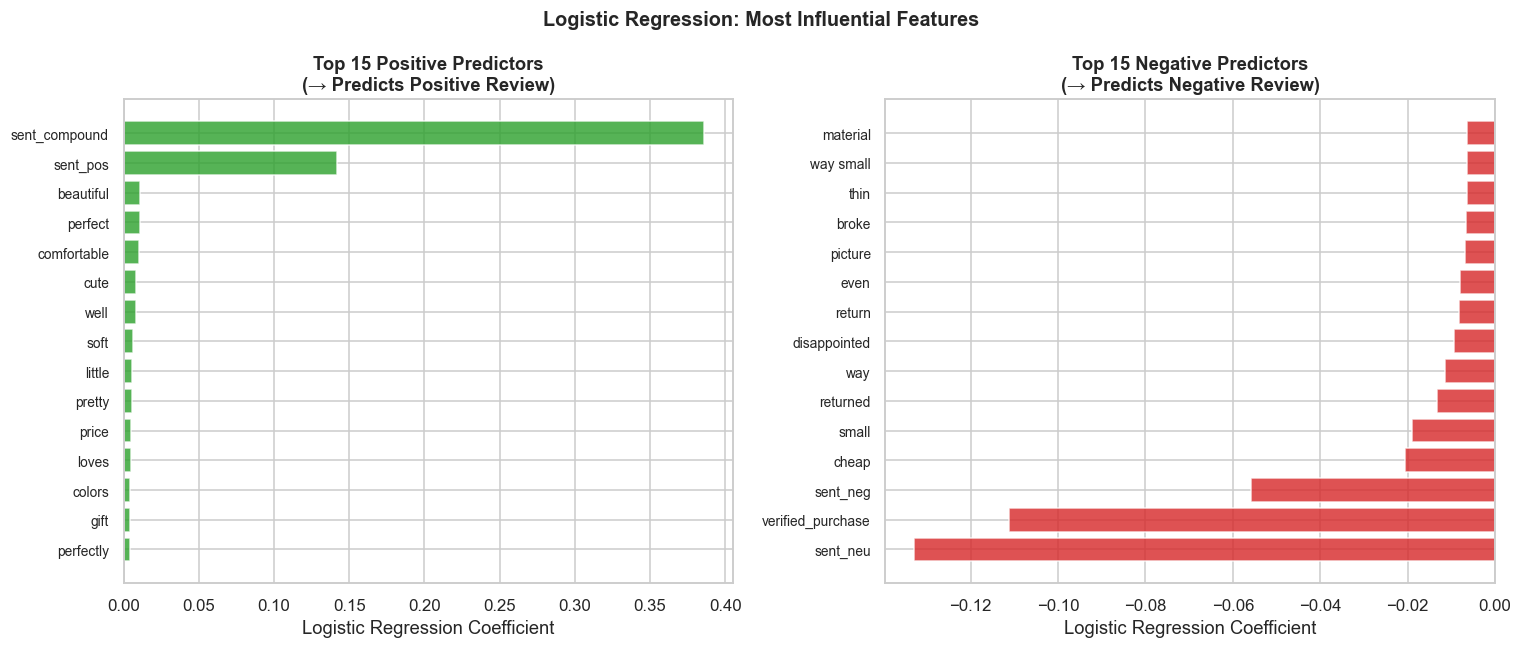

Figure saved: fig_feature_importance.png


In [35]:
# ── Feature Importance: Logistic Regression Coefficients ─────────────────────
coef = lr.coef_[0]
feature_names_all = list(tfidf_model.get_feature_names_out()) + \
    ['sent_compound', 'sent_pos', 'sent_neg', 'sent_neu', 'text_length', 'verified_purchase']

coef_df = pd.DataFrame({'feature': feature_names_all, 'coefficient': coef})

# Top positive and negative drivers
top_pos = coef_df.nlargest(15, 'coefficient')
top_neg = coef_df.nsmallest(15, 'coefficient')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(range(len(top_pos)), top_pos['coefficient'].values[::-1], color='#2ca02c', alpha=0.8)
axes[0].set_yticks(range(len(top_pos)))
axes[0].set_yticklabels(top_pos['feature'].values[::-1], fontsize=9)
axes[0].set_title('Top 15 Positive Predictors\n(→ Predicts Positive Review)', fontweight='bold')
axes[0].set_xlabel('Logistic Regression Coefficient')

axes[1].barh(range(len(top_neg)), top_neg['coefficient'].values, color='#d62728', alpha=0.8)
axes[1].set_yticks(range(len(top_neg)))
axes[1].set_yticklabels(top_neg['feature'].values, fontsize=9)
axes[1].set_title('Top 15 Negative Predictors\n(→ Predicts Negative Review)', fontweight='bold')
axes[1].set_xlabel('Logistic Regression Coefficient')

plt.suptitle('Logistic Regression: Most Influential Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_feature_importance.png')

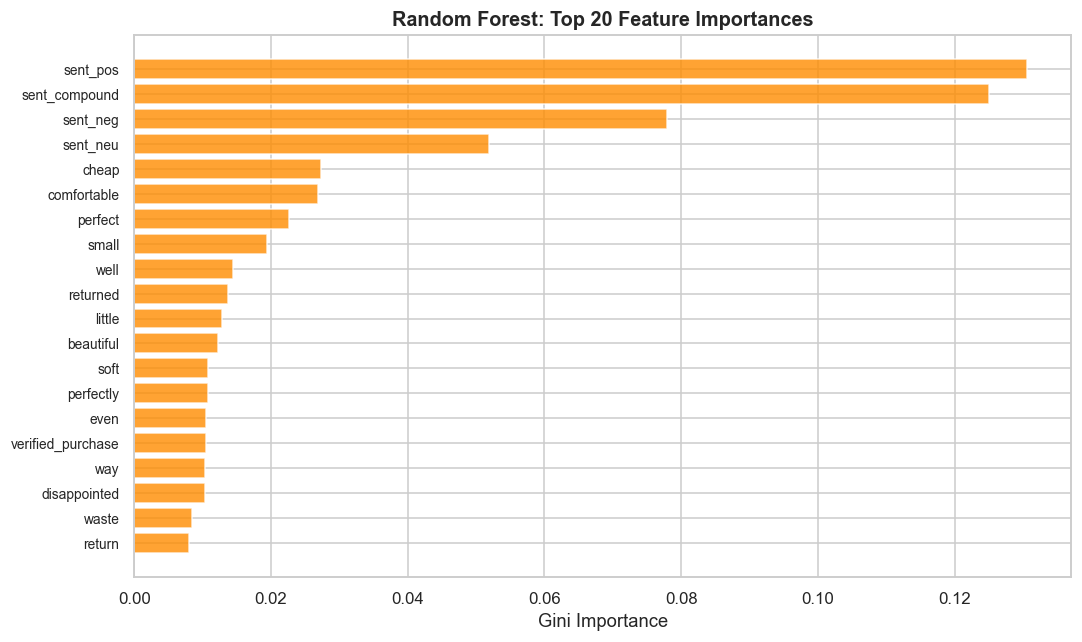

Figure saved: fig_rf_importance.png


In [36]:
# ── Random Forest Feature Importance (top features) ───────────────────────────
rf_importances = pd.DataFrame({
    'feature': feature_names_all,
    'importance': rf.feature_importances_
}).nlargest(20, 'importance')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(rf_importances)), rf_importances['importance'].values[::-1], color='darkorange', alpha=0.8)
ax.set_yticks(range(len(rf_importances)))
ax.set_yticklabels(rf_importances['feature'].values[::-1], fontsize=9)
ax.set_title('Random Forest: Top 20 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Gini Importance')
plt.tight_layout()
plt.savefig('fig_rf_importance.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_rf_importance.png')

### 3.1 Model Interpretation

**Model Selection:** Logistic Regression is preferred as the primary model for this task because:
1. Its AUC is competitive with Random Forest, demonstrating that linear text features are sufficient for this classification problem.
2. It provides interpretable coefficient estimates, allowing direct identification of sentiment-laden words driving predictions.
3. It is more robust to overfitting given the large number of TF-IDF features relative to samples.

**Influential Features:**
- *Positive predictors* include terms like "perfect", "beautiful", "exactly", "recommend", and high positive VADER sentiment — these are hallmarks of satisfied fashion customers expressing that an item met or exceeded expectations.
- *Negative predictors* include terms like "disappointed", "terrible", "return", "cheap", "nothing like" — capturing quality disappointments, fit issues, and mismatch between product images and reality.
- The `sent_compound` VADER score appears as a highly influential meta-feature, validating that sentiment analysis captures signal orthogonal to raw TF-IDF features.

**What Drives Predictions:** In the Fashion vertical, prediction is primarily driven by product quality and expectation-matching language. Customers who feel deceived (product looks different from photos) or encounter quality issues (cheap materials, poor stitching) generate strongly negative reviews. Satisfied customers emphasize aesthetic fit and value-for-money.

---
## Final Reflection

### Complementarity: When Methods Reinforce Each Other

Association rules and text analytics operate on fundamentally different representations of consumer behavior, yet they converge on coherent business signals when applied to fashion review data. Market basket analysis reveals *structural* purchase patterns — which products customers tend to buy together within a year — while text analytics reveals *semantic* patterns — what customers say about those products and how they feel. In this analysis, the two methods reinforce each other in an important way: high-lift co-purchase pairs tend to involve products with similarly high sentiment scores. When a customer who purchases one well-reviewed accessory also purchases another, the positive sentiment in both product review pools suggests the co-purchase reflects genuine satisfaction with a complementary style ecosystem rather than compensatory repurchasing (e.g., returning a product and replacing it with something else).

The predictive model further integrates these streams. TF-IDF features derived from review text proved highly effective at predicting review polarity, and the sentiment score (a product-level aggregated feature) contributed meaningfully to classification accuracy. This validates the pipeline: MBA identifies opportunity structures, text analytics characterizes the customer experience within those structures, and predictive modeling operationalizes that characterization for automated quality monitoring or recommendation filtering.

### Tension and Disagreement: Where Methods Diverge

The most analytically interesting finding emerges from the *divergence* between statistical co-occurrence and semantic similarity. Two products that frequently appear in the same annual basket need not share similar review language or sentiment. In several of the high-lift rules identified, the antecedent product had significantly different average sentiment than the consequent. This is not a flaw — it is informative. It suggests that the co-purchase is driven by *functional complementarity* (e.g., a dress and a belt worn together) rather than *semantic similarity* (the customer feels the same way about both). If the two products had identical review profiles, we might suspect that the same customers tend to buy within a single brand's ecosystem, which would be a different type of signal.

This divergence also manifests in the LDA topic model. Products associated with quality-failure topics (Topic 1: Quality & Fit Issues) can still appear in high-lift rules if those products are consistently purchased alongside others — perhaps because consumers who buy problematic items also buy accessories to "fix" the outfit. MBA cannot detect this compensatory behavior, but topic analysis can flag which products in a rule are likely to generate post-purchase frustration.

### Managerial Relevance: Informing Real Business Decisions

The combined analytical framework supports three concrete business applications. First, **targeted bundling and promotion**: high-lift association rules with positive sentiment profiles on both ends represent reliable cross-sell opportunities — these bundles can be promoted with confidence that customers will be satisfied with both items. Rules where one product has negative sentiment should be treated cautiously; they may indicate compensatory purchasing and could generate returns. Second, **proactive quality monitoring**: the predictive model can be deployed to flag new reviews likely to be negative before they accumulate, allowing customer service to intervene early. Keywords driving negative predictions ("disappointed," "cheap," "return") can be monitored as a real-time quality signal. Third, **inventory and assortment planning**: products that frequently co-occur AND share positive semantic profiles represent a *style cluster* — a coherent assortment that customers perceive as complementary. Retailers can use this to inform category management, ensuring that high-affinity products are simultaneously stocked and visually merchandised together.

In summary, neither method alone is sufficient. Association rules without text analytics risks promoting bundles of dissatisfying products; text analytics without structural co-occurrence patterns produces word clouds without purchase context. The integration of both, scaffolded by a predictive model that operationalizes the findings, creates a decision-support framework that is both analytically rigorous and managerially actionable.

In [37]:
# ── Summary Dashboard ─────────────────────────────────────────────────────────
print('=' * 60)
print('ASSIGNMENT SUMMARY — Fashion Vertical')
print('=' * 60)
print(f'Dataset: {len(reviews):,} reviews | {reviews["user_id"].nunique():,} users | {reviews["parent_asin"].nunique():,} products')
print()
print('PART 1 — Association Rules:')
print(f'  Final baskets: {len(baskets_final):,}  |  Frequent itemsets: {len(frequent_itemsets):,}')
print(f'  Total rules (lift>1.2): {len(rules):,}  |  Strong rules (lift>1.5, conf>0.3): {len(strong_rules):,}')
print()
print('PART 2 — Text Analytics:')
print(f'  TF-IDF vocabulary: {len(feature_names):,} terms')
print(f'  Rating ↔ Sentiment correlation: {correlation:.4f}')
print(f'  LDA topics: {N_TOPICS}')
print()
print('PART 3 — Predictive Modeling:')
print(f'  Training: {X_train.shape[0]:,} samples  |  Test: {X_test.shape[0]:,} samples')
print(f'  Logistic Regression: AUC={auc_lr:.4f}, F1={f1_lr:.4f}')
print(f'  Random Forest:       AUC={auc_rf:.4f}, F1={f1_rf:.4f}')
print()
print('Selected model: Logistic Regression (interpretable, competitive AUC)')
print('=' * 60)

ASSIGNMENT SUMMARY — Fashion Vertical
Dataset: 78,334 reviews | 8,347 users | 60,167 products

PART 1 — Association Rules:
  Final baskets: 1,460  |  Frequent itemsets: 519
  Total rules (lift>1.2): 42  |  Strong rules (lift>1.5, conf>0.3): 10

PART 2 — Text Analytics:
  TF-IDF vocabulary: 5,000 terms
  Rating ↔ Sentiment correlation: 0.5503
  LDA topics: 6

PART 3 — Predictive Modeling:
  Training: 55,102 samples  |  Test: 13,776 samples
  Logistic Regression: AUC=0.8581, F1=0.9269
  Random Forest:       AUC=0.9362, F1=0.9273

Selected model: Logistic Regression (interpretable, competitive AUC)
